In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score , f1_score  , recall_score

from sklearn.tree import DecisionTreeClassifier

In [6]:
data = pd.read_csv("shop_smart_ecommerce.csv")

# I am hired as a machine learning Engineer to make a predective model that can determine wheather a visitor will make a purchase on the session behaviour or not

In [7]:
data

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [8]:
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## EDA

In [10]:
visitor_count = data["VisitorType"].value_counts()
visitor_count

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

In [11]:
 data.groupby(['VisitorType' , 'Revenue']).size().unstack(fill_value=0)

Revenue,False,True
VisitorType,,
New_Visitor,1272,422
Other,69,16
Returning_Visitor,9081,1470


In [12]:
# % of vesitors who generated revenue in each category
convergen_rate = data.groupby('VisitorType')['Revenue'].mean()
convergen_rate

VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

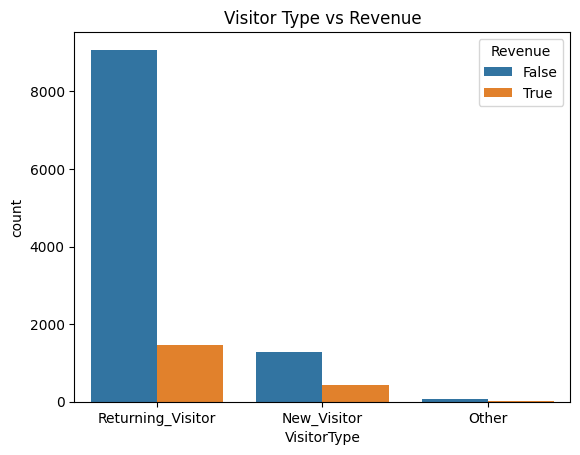

In [13]:

sns.countplot(x='VisitorType', hue='Revenue', data=data)
plt.title("Visitor Type vs Revenue")
plt.show()


In [14]:
# weekend revenue generated 
data.groupby(['Weekend', 'Revenue']).size()


Weekend  Revenue
False    False      8053
         True       1409
True     False      2369
         True        499
dtype: int64

In [15]:
data.groupby(['Weekend', 'Revenue']).size().unstack(fill_value=0)
# what is the use of unstack here
# it pivote one level of index into coloumns - mens 1 level index ko clm me daal deta hai so that it is easir to read

Revenue,False,True
Weekend,,
False,8053,1409
True,2369,499


Conversion Rate :  Weekend
False    0.148911
True     0.173989
Name: Revenue, dtype: float64


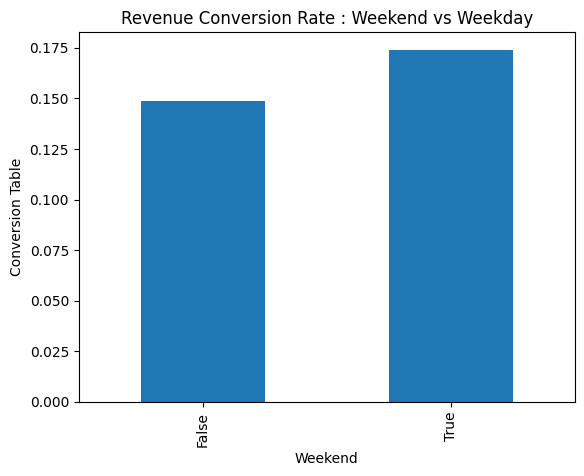

In [16]:
conversion_rate = data.groupby("Weekend")["Revenue"].mean()

print("Conversion Rate : " , conversion_rate)

conversion_rate.plot(kind = 'bar')
plt.ylabel("Conversion Table")
plt.title("Revenue Conversion Rate : Weekend vs Weekday")
plt.show()

In [17]:
conversion_rate_months = data.groupby("Month")["Revenue"].mean()
conversion_rate_months

Month
Aug     0.175520
Dec     0.125072
Feb     0.016304
Jul     0.152778
June    0.100694
Mar     0.100682
May     0.108502
Nov     0.253502
Oct     0.209472
Sep     0.191964
Name: Revenue, dtype: float64

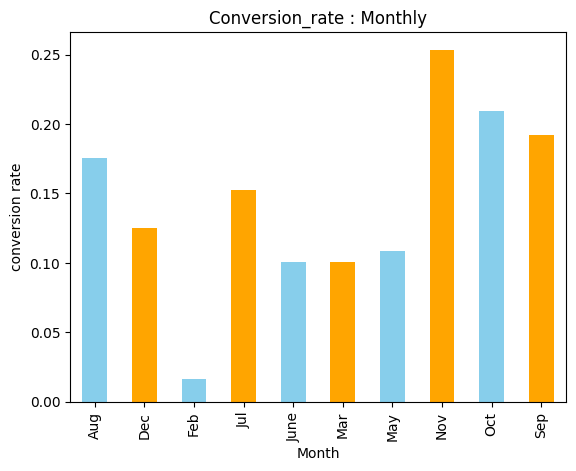

In [18]:
conversion_rate_months.plot(kind = "bar" , color = ["skyblue" , "orange"])
plt.ylabel("conversion rate")
plt.title("Conversion_rate : Monthly")
plt.show()

In [19]:
# creating box plot to check if their exist an outlier in the data in any of the categorical data

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

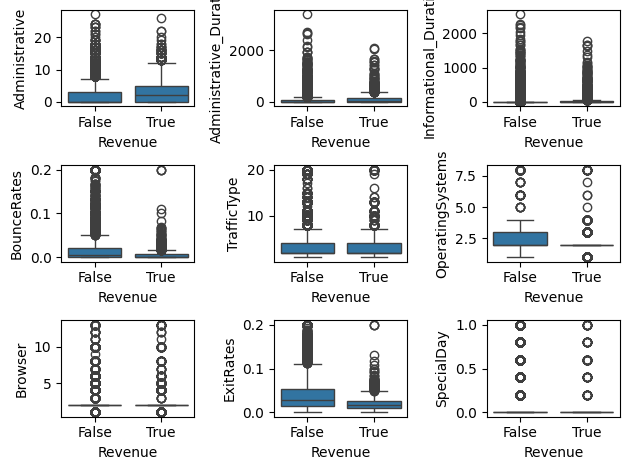

In [20]:
fig , axes = plt.subplots(3 ,3)

sns.boxplot(ax = axes[0,0] , data = data , x = "Revenue" , y = "Administrative")
sns.boxplot(ax = axes[0,1] , data = data , x = "Revenue" , y = "Administrative_Duration")
sns.boxplot(ax = axes[0,2] , data = data, x = "Revenue" , y = "Informational_Duration")
sns.boxplot(ax = axes[1,0] , data = data , x = "Revenue" , y = "BounceRates")
sns.boxplot(ax = axes[1,1] , data= data  , x = "Revenue" , y = "TrafficType")
sns.boxplot(ax = axes[1,2] , data = data, x = "Revenue" , y = "OperatingSystems")
sns.boxplot(ax = axes[2,0] , data = data, x = "Revenue" , y = "Browser")
sns.boxplot(ax = axes[2,1] , data = data, x = "Revenue" , y = "ExitRates")
sns.boxplot(ax = axes[2,2] , data = data, x = "Revenue" , y = "SpecialDay")

plt.tight_layout()

# Data Preprocessing  

Data is alreadt cleaned their are no duplicated values  , their are values , 
though their are categorical data we have to convert then into numerical data
# 1. Feature Engineering - Binary Encoding/laber Encoding 
- for Binary Data

In [21]:
le = LabelEncoder()
data["Weekend"] = le.fit_transform(data["Weekend"])
data["Revenue"] = le.fit_transform(data["Revenue"])


cols = ["Month" , "VisitorType"]

ohe = OneHotEncoder(drop = "first" , sparse_output=False , handle_unknown='ignore')
encoded= ohe.fit_transform(data[cols])

# encoded is  a 2D marix we have to convet it to data frame
Encoded_data = pd.DataFrame(encoded , columns = ohe. get_feature_names_out(cols) , index = data.index)

# now we have to concatinate the Encoded data 

data = pd.concat([data.drop(columns = cols) , Encoded_data] , axis = 1)



In [22]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [23]:
numerical_cols = data.select_dtypes("number")

# we will make correlational matrix
corr_matrix = numerical_cols.corr()

<Axes: >

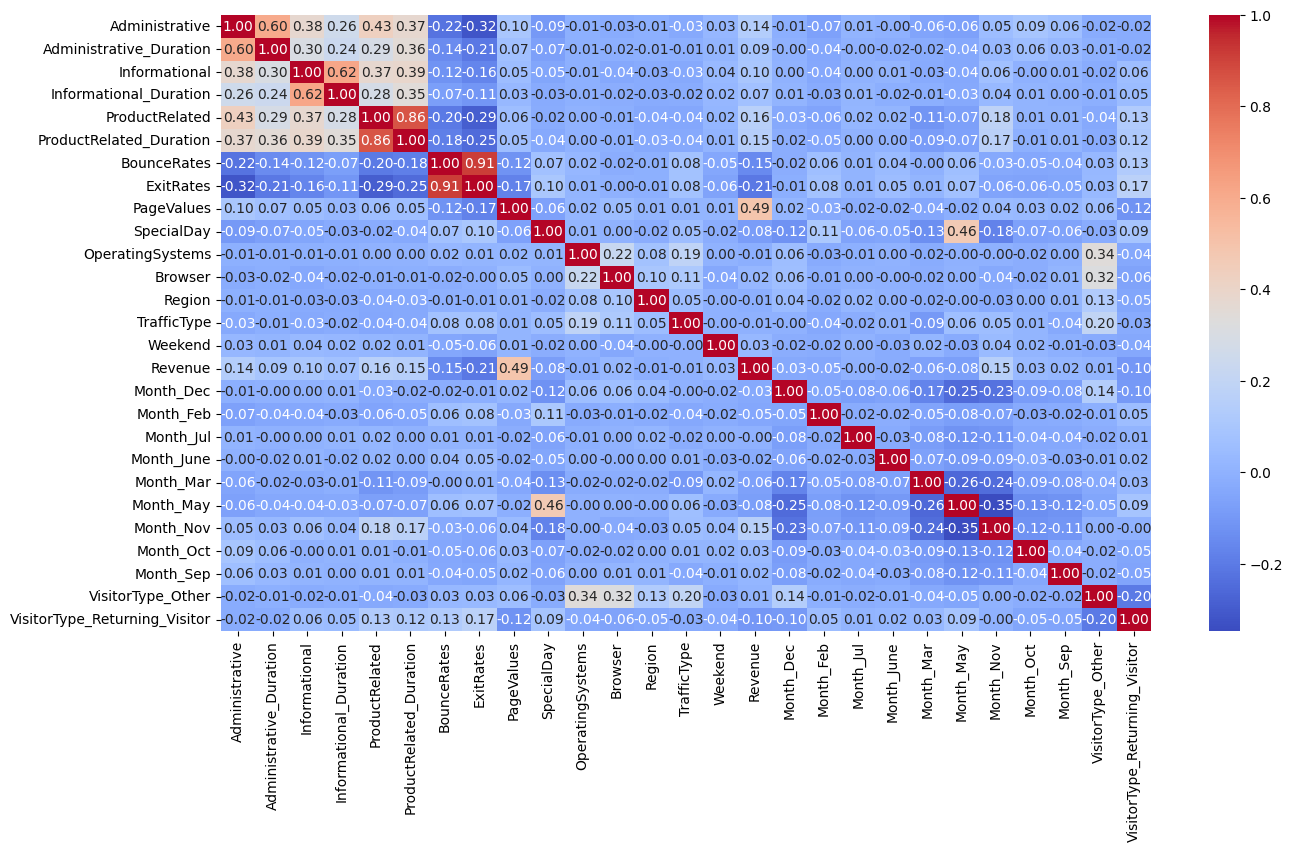

In [24]:
plt.figure(figsize=(15 , 8))
sns.heatmap(
    corr_matrix,
    annot= True ,
    fmt = ".2f",
    cmap = "coolwarm"
)

# Spliting and traning the data

In [25]:
X = data.drop("Revenue" , axis = 1)
Y = data["Revenue"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [26]:
model = DecisionTreeClassifier()
model.fit(X_train , Y_train)

Y_predicted = model.predict(X_test)
print("accuracy: ", accuracy_score(Y_test, Y_predicted))
print("f1_score :" , f1_score(Y_test , Y_predicted))

accuracy:  0.8540145985401459
f1_score : 0.5652173913043478


# Pre-Prunning

In [27]:
Best_depth = [2,3,4,5,6,7,8,9]
best_score =  0.0
best_depth = 0 
for depth in Best_depth:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train , Y_train)
    score = f1_score(Y_test , Y_predicted)
    print(f"model {depth} : score : {score}")
    if best_score < score :
        best_score = score
        best_depth = depth

print(f"Best score is  : {best_score} in the depth : {best_depth}")




model 2 : score : 0.5652173913043478
model 3 : score : 0.5652173913043478
model 4 : score : 0.5652173913043478
model 5 : score : 0.5652173913043478
model 6 : score : 0.5652173913043478
model 7 : score : 0.5652173913043478
model 8 : score : 0.5652173913043478
model 9 : score : 0.5652173913043478
Best score is  : 0.5652173913043478 in the depth : 2


# POST PRUNNING

In [28]:
Full_tree = DecisionTreeClassifier(random_state = 42)
Full_tree.fit(X_train , Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [31]:
path = Full_tree.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas) # here we have to train a model in for every alpha value and select the value one with the highest test accuracy


[0.00000000e+00 5.04680245e-05 6.60140704e-05 6.67684446e-05
 6.67907066e-05 6.69232278e-05 6.70578197e-05 6.72124316e-05
 6.73418418e-05 6.74631737e-05 7.85090604e-05 7.89964294e-05
 8.68960723e-05 8.72536693e-05 8.87064071e-05 8.87064071e-05
 8.87064071e-05 8.96812028e-05 9.01144453e-05 9.01144453e-05
 9.01144453e-05 9.01144453e-05 9.01144453e-05 9.07982102e-05
 9.21625009e-05 9.32684509e-05 9.33751654e-05 9.35803856e-05
 9.35803856e-05 9.35803856e-05 9.35803856e-05 9.38692139e-05
 9.41374117e-05 9.41374117e-05 9.41374117e-05 9.44980879e-05
 9.46201676e-05 9.50425791e-05 9.50425791e-05 9.50425791e-05
 9.54152951e-05 9.55182436e-05 9.57465982e-05 9.58810312e-05
 9.60178457e-05 9.60430273e-05 9.60430273e-05 9.61798407e-05
 9.63098135e-05 9.67706260e-05 9.69709792e-05 9.72408428e-05
 9.73236010e-05 9.74795683e-05 9.78829320e-05 9.79633172e-05
 9.79994593e-05 9.81084687e-05 9.81084687e-05 9.82594048e-05
 9.83066676e-05 9.83525196e-05 9.85852032e-05 9.87088721e-05
 9.89060986e-05 9.922175

In [36]:
# we train our model for all alpha values
trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42 , ccp_alpha = alpha)
    model.fit(X_train , Y_train)
    trees.append((model , alpha)) # here we will get our model for their alpha values

best_accuracy = 0 
best_alpha = 0 
for model, alpha in trees:
    current_accuracy = model.score(X_test , Y_test)
    if current_accuracy > best_accuracy :
        best_accuracy = current_accuracy
        best_aplha = alpha
print(best_alpha)
print("best_acuracy :" , best_accuracy)

0
best_acuracy : 0.8961881589618816


In [37]:
best_model = DecisionTreeClassifier(random_state= 42 , ccp_alpha = best_alpha)
best_model.fit(X_train , Y_train)

Y_predicted = best_model.predict(X_test)

print("accuracy: ", accuracy_score(Y_test, Y_predicted))
print("f1_score :" , f1_score(Y_test , Y_predicted))


accuracy:  0.8588807785888077
f1_score : 0.5827338129496403
